In [2]:
!pip install -q boto3 s3fs pandas pyarrow xarray netCDF4 zarr

In [4]:
import os
import re
import math
import json
import tempfile
from datetime import datetime
from pathlib import Path

import boto3
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from botocore import UNSIGNED
from botocore.config import Config
from tqdm import tqdm

PUBLIC_BUCKET = "nsf-ncar-era5"
PUBLIC_REGION = "us-west-2"

s3_public = boto3.client(
    "s3",
    region_name=PUBLIC_REGION,
    config=Config(signature_version=UNSIGNED)
)

# Quick test
resp = s3_public.list_objects_v2(
    Bucket=PUBLIC_BUCKET,
    MaxKeys=10
)

[o["Key"] for o in resp.get("Contents", [])]



['e5.oper.an.pl/',
 'e5.oper.an.pl/194001/',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010100_1940010123.nc',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010200_1940010223.nc',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010300_1940010323.nc',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010400_1940010423.nc',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010500_1940010523.nc',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010600_1940010623.nc',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010700_1940010723.nc',
 'e5.oper.an.pl/194001/e5.oper.an.pl.128_060_pv.ll025sc.1940010800_1940010823.nc']

In [5]:
# Project scope
YEAR = 2023
MONTH = 1

# Vietnam rough bounding box
# longitude: 102–110 E
# latitude: 8–24 N
LAT_MIN = 8.0
LAT_MAX = 24.0
LON_MIN = 102.0
LON_MAX = 110.0

LOCAL_DATA_DIR = Path("data")
LOCAL_DATA_DIR.mkdir(exist_ok=True)

OUTPUT_PARQUET = LOCAL_DATA_DIR / f"era5_vietnam_daily_{YEAR}_{MONTH:02d}.parquet"

In [6]:
def list_prefix(prefix, max_keys=50):
    response = s3_public.list_objects_v2(
        Bucket=PUBLIC_BUCKET,
        Prefix=prefix,
        MaxKeys=max_keys
    )
    return [obj["Key"] for obj in response.get("Contents", [])]

# First-level exploration
top_keys = list_prefix("", max_keys=50)
top_keys[:20]


candidate_prefixes = [
    f"e5.oper.an.sfc/{YEAR}{MONTH:02d}/",
    f"e5.oper.an.sfc/{YEAR}/{MONTH:02d}/",
    f"e5.oper.an.sfc/{YEAR}/",
    f"{YEAR}/",
]

for p in candidate_prefixes:
    keys = list_prefix(p, max_keys=10)
    print("\nPREFIX:", p)
    print(keys[:5])


PREFIX: e5.oper.an.sfc/202301/
['e5.oper.an.sfc/202301/e5.oper.an.sfc.128_015_aluvp.ll025sc.2023010100_2023013123.nc', 'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_016_aluvd.ll025sc.2023010100_2023013123.nc', 'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_017_alnip.ll025sc.2023010100_2023013123.nc', 'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_018_alnid.ll025sc.2023010100_2023013123.nc', 'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_031_ci.ll025sc.2023010100_2023013123.nc']

PREFIX: e5.oper.an.sfc/2023/01/
[]

PREFIX: e5.oper.an.sfc/2023/
[]

PREFIX: 2023/
[]


In [7]:
def paginate_keys(prefix):
    paginator = s3_public.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=PUBLIC_BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            yield obj["Key"]

# Usually surface analysis files are under e5.oper.an.sfc/
SEARCH_PREFIX = f"e5.oper.an.sfc/{YEAR}{MONTH:02d}/"

keys = list(paginate_keys(SEARCH_PREFIX))
len(keys), keys[:10]

(62,
 ['e5.oper.an.sfc/202301/e5.oper.an.sfc.128_015_aluvp.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_016_aluvd.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_017_alnip.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_018_alnid.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_031_ci.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_032_asn.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_033_rsn.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_034_sstk.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_035_istl1.ll025sc.2023010100_2023013123.nc',
  'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_036_istl2.ll025sc.2023010100_2023013123.nc'])

In [8]:
for k in keys[:50]:
    print(k)

e5.oper.an.sfc/202301/e5.oper.an.sfc.128_015_aluvp.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_016_aluvd.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_017_alnip.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_018_alnid.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_031_ci.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_032_asn.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_033_rsn.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_034_sstk.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_035_istl1.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_036_istl2.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_037_istl3.ll025sc.2023010100_2023013123.nc
e5.oper.an.sfc/202301/e5.oper.an.sfc.128_038_istl4.ll025sc.2023010100_2023013123.nc


### Identifying relevant data files

Based on your requirements, we are looking for files containing data for:

*   2m temperature
*   total precipitation
*   10m u wind
*   10m v wind
*   surface solar radiation downwards

For the MVP, we will focus on **2m temperature** and **total precipitation**.

ERA5 data files often include a parameter code and a short variable name. Based on common ERA5 conventions and the observed file names, we can map the desired variables to these patterns.

In [9]:
variable_file_patterns = {
    "2m temperature": "_167_2t",
    "total precipitation": "_228_tp", # This is a common code for total precipitation in ERA5
    "10m u wind": "_165_10u",
    "10m v wind": "_166_10v",
    "surface solar radiation downwards": "_244_fsr"
}

found_files = {}
for var_name, pattern in variable_file_patterns.items():
    for k in keys:
        if pattern in k:
            found_files[var_name] = k
            break

print("Identified files for requested variables:")
for var, file_key in found_files.items():
    print(f"- {var}: {file_key}")

mvp_files = {}
if "2m temperature" in found_files:
    mvp_files["2m temperature"] = found_files["2m temperature"]
else:
    print("\nWarning: 2m temperature file not found!")

if "total precipitation" in found_files:
    mvp_files["total precipitation"] = found_files["total precipitation"]
else:
    print("\nWarning: Total precipitation file not found! It is typically denoted by '_228_tp'.")

print("\nFiles for MVP (2m temperature and total precipitation):")
if mvp_files:
    for var, file_key in mvp_files.items():
        print(f"- {var}: {file_key}")
else:
    print("No files found for MVP variables.")


Identified files for requested variables:
- 2m temperature: e5.oper.an.sfc/202301/e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2023013123.nc
- 10m u wind: e5.oper.an.sfc/202301/e5.oper.an.sfc.128_165_10u.ll025sc.2023010100_2023013123.nc
- 10m v wind: e5.oper.an.sfc/202301/e5.oper.an.sfc.128_166_10v.ll025sc.2023010100_2023013123.nc
- surface solar radiation downwards: e5.oper.an.sfc/202301/e5.oper.an.sfc.128_244_fsr.ll025sc.2023010100_2023013123.nc


Files for MVP (2m temperature and total precipitation):
- 2m temperature: e5.oper.an.sfc/202301/e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2023013123.nc


In [10]:
sample_keys = [k for k in keys if k.endswith(".nc")][:5]
sample_keys

def download_s3_public(key, local_dir=LOCAL_DATA_DIR):
    local_path = local_dir / Path(key).name
    if local_path.exists():
        return local_path

    print(f"Downloading s3://{PUBLIC_BUCKET}/{key}")
    s3_public.download_file(PUBLIC_BUCKET, key, str(local_path))
    return local_path

local_files = [download_s3_public(k) for k in sample_keys]
local_files

[PosixPath('data/e5.oper.an.sfc.128_015_aluvp.ll025sc.2023010100_2023013123.nc'),
 PosixPath('data/e5.oper.an.sfc.128_016_aluvd.ll025sc.2023010100_2023013123.nc'),
 PosixPath('data/e5.oper.an.sfc.128_017_alnip.ll025sc.2023010100_2023013123.nc'),
 PosixPath('data/e5.oper.an.sfc.128_018_alnid.ll025sc.2023010100_2023013123.nc'),
 PosixPath('data/e5.oper.an.sfc.128_031_ci.ll025sc.2023010100_2023013123.nc')]

In [11]:
from pathlib import Path

def download_s3_public(key, local_dir=LOCAL_DATA_DIR):
    local_path = local_dir / Path(key).name
    if local_path.exists():
        return local_path

    print(f"Downloading s3://{PUBLIC_BUCKET}/{key}")
    s3_public.download_file(PUBLIC_BUCKET, key, str(local_path))
    return local_path

selected_keys = [
    found_files['2m temperature'],
    found_files['10m u wind'],
    found_files['10m v wind'],
    found_files['surface solar radiation downwards'],
]

print(selected_keys)

local_files = [download_s3_public(k) for k in selected_keys]
local_files

['e5.oper.an.sfc/202301/e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2023013123.nc', 'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_165_10u.ll025sc.2023010100_2023013123.nc', 'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_166_10v.ll025sc.2023010100_2023013123.nc', 'e5.oper.an.sfc/202301/e5.oper.an.sfc.128_244_fsr.ll025sc.2023010100_2023013123.nc']


[PosixPath('data/e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2023013123.nc'),
 PosixPath('data/e5.oper.an.sfc.128_165_10u.ll025sc.2023010100_2023013123.nc'),
 PosixPath('data/e5.oper.an.sfc.128_166_10v.ll025sc.2023010100_2023013123.nc'),
 PosixPath('data/e5.oper.an.sfc.128_244_fsr.ll025sc.2023010100_2023013123.nc')]

In [12]:
for fp in local_files:
    print("\nFILE:", fp)
    ds = xr.open_dataset(fp)
    print(ds)
    print("Variables:", list(ds.data_vars))
    ds.close()


FILE: data/e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2023013123.nc
<xarray.Dataset> Size: 3GB
Dimensions:    (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2023-01-01 ... 2023-01-31T23:00:00
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    VAR_2T     (time, latitude, longitude) float32 3GB ...
    utc_date   (time) int32 3kB ...
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.8.1
    CONVERSION_PLATFORM:  Linux r1i2n21 4.12.14-95.51-default #1 SMP Fri Apr ...
    CONVERSION_DATE:      Sat Apr 15 16:16:54 MDT 2023
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Sat 

In [13]:
def detect_lat_lon_names(ds):
    lat_candidates = ["latitude", "lat", "g0_lat_1", "gridlat_0"]
    lon_candidates = ["longitude", "lon", "g0_lon_2", "gridlon_0"]

    lat_name = None
    lon_name = None

    for c in lat_candidates:
        if c in ds.coords or c in ds.variables:
            lat_name = c
            break

    for c in lon_candidates:
        if c in ds.coords or c in ds.variables:
            lon_name = c
            break

    if lat_name is None or lon_name is None:
        print(ds)
        raise ValueError("Could not detect latitude/longitude coordinate names.")

    return lat_name, lon_name


def subset_vietnam(ds):
    lat_name, lon_name = detect_lat_lon_names(ds)

    # Handle latitude ascending or descending
    lat_values = ds[lat_name].values
    if lat_values[0] > lat_values[-1]:
        ds = ds.sel({lat_name: slice(LAT_MAX, LAT_MIN)})
    else:
        ds = ds.sel({lat_name: slice(LAT_MIN, LAT_MAX)})

    lon_values = ds[lon_name].values

    # ERA5 longitude usually 0–360, Vietnam is 102–110, so this is fine
    ds = ds.sel({lon_name: slice(LON_MIN, LON_MAX)})

    return ds

In [14]:
def dataset_to_daily_summary(local_file):
    ds = xr.open_dataset(local_file)
    ds = subset_vietnam(ds)

    # Detect time coordinate
    time_candidates = ["time", "valid_time", "initial_time0_hours"]
    time_name = None
    for c in time_candidates:
        if c in ds.coords or c in ds.variables:
            time_name = c
            break

    if time_name is None:
        print(ds)
        raise ValueError("Could not detect time coordinate.")

    rows = []

    for var_name in ds.data_vars:
        da = ds[var_name]

        # Spatial mean over Vietnam bbox
        dims_to_mean = []
        for dim in da.dims:
            if dim != time_name:
                # only average spatial-like dims
                if dim in ds.coords or "lat" in dim.lower() or "lon" in dim.lower():
                    dims_to_mean.append(dim)

        # Simpler fallback: average every dimension except time
        if len(dims_to_mean) == 0:
            dims_to_mean = [d for d in da.dims if d != time_name]

        series = da.mean(dim=dims_to_mean, skipna=True)

        df_var = series.to_dataframe(name="value").reset_index()
        df_var["variable"] = var_name
        df_var["source_file"] = Path(local_file).name

        # Standardize time column
        df_var = df_var.rename(columns={time_name: "datetime"})
        df_var["datetime"] = pd.to_datetime(df_var["datetime"])
        df_var["date"] = df_var["datetime"].dt.date

        rows.append(df_var[["datetime", "date", "variable", "value", "source_file"]])

    ds.close()

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)

all_hourly = []

for fp in local_files:
    print("Processing", fp)
    df_part = dataset_to_daily_summary(fp)
    all_hourly.append(df_part)

hourly_df = pd.concat(all_hourly, ignore_index=True)
hourly_df.head(), hourly_df.shape

Processing data/e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2023013123.nc
Processing data/e5.oper.an.sfc.128_165_10u.ll025sc.2023010100_2023013123.nc
Processing data/e5.oper.an.sfc.128_166_10v.ll025sc.2023010100_2023013123.nc
Processing data/e5.oper.an.sfc.128_244_fsr.ll025sc.2023010100_2023013123.nc


(             datetime        date variable       value  \
 0 2023-01-01 00:00:00  2023-01-01   VAR_2T  290.563110   
 1 2023-01-01 01:00:00  2023-01-01   VAR_2T  290.756592   
 2 2023-01-01 02:00:00  2023-01-01   VAR_2T  292.810883   
 3 2023-01-01 03:00:00  2023-01-01   VAR_2T  293.363647   
 4 2023-01-01 04:00:00  2023-01-01   VAR_2T  293.644409   
 
                                          source_file  
 0  e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2...  
 1  e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2...  
 2  e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2...  
 3  e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2...  
 4  e5.oper.an.sfc.128_167_2t.ll025sc.2023010100_2...  ,
 (5952, 5))

In [15]:
daily_df = (
    hourly_df
    .groupby(["date", "variable"], as_index=False)
    .agg(
        avg_value=("value", "mean"),
        min_value=("value", "min"),
        max_value=("value", "max"),
        sum_value=("value", "sum"),
        n_obs=("value", "count")
    )
)

daily_df["region"] = "Vietnam"
daily_df["lat_min"] = LAT_MIN
daily_df["lat_max"] = LAT_MAX
daily_df["lon_min"] = LON_MIN
daily_df["lon_max"] = LON_MAX
daily_df["year"] = YEAR
daily_df["month"] = MONTH
daily_df["ingestion_time"] = pd.Timestamp.utcnow()

daily_df.head()

,date,variable,avg_value,min_value,max_value,sum_value,n_obs,region,lat_min,lat_max,lon_min,lon_max,year,month,ingestion_time
0,2023-01-01,FSR,6.444677e-01,6.434405e-01,6.448546e-01,1.546722e+01,24,Vietnam,8.0,24.0,102.0,110.0,2023,1,2026-05-04 21:51:50.038060+00:00
1,2023-01-01,VAR_10U,-1.616552e+00,-1.824669e+00,-1.337726e+00,-3.879725e+01,24,Vietnam,8.0,24.0,102.0,110.0,2023,1,2026-05-04 21:51:50.038060+00:00
2,2023-01-01,VAR_10V,-3.346416e+00,-3.733628e+00,-3.058575e+00,-8.031400e+01,24,Vietnam,8.0,24.0,102.0,110.0,2023,1,2026-05-04 21:51:50.038060+00:00
3,2023-01-01,VAR_2T,2.930490e+02,2.905631e+02,2.955935e+02,7.033175e+03,24,Vietnam,8.0,24.0,102.0,110.0,2023,1,2026-05-04 21:51:50.038060+00:00
4,2023-01-01,utc_date,2.023010e+09,2.023010e+09,2.023010e+09,1.942090e+11,96,Vietnam,8.0,24.0,102.0,110.0,2023,1,2026-05-04 21:51:50.038060+00:00


In [16]:
daily_df.to_parquet(OUTPUT_PARQUET, index=False)
print("Saved:", OUTPUT_PARQUET)

Saved: data/era5_vietnam_daily_2023_01.parquet


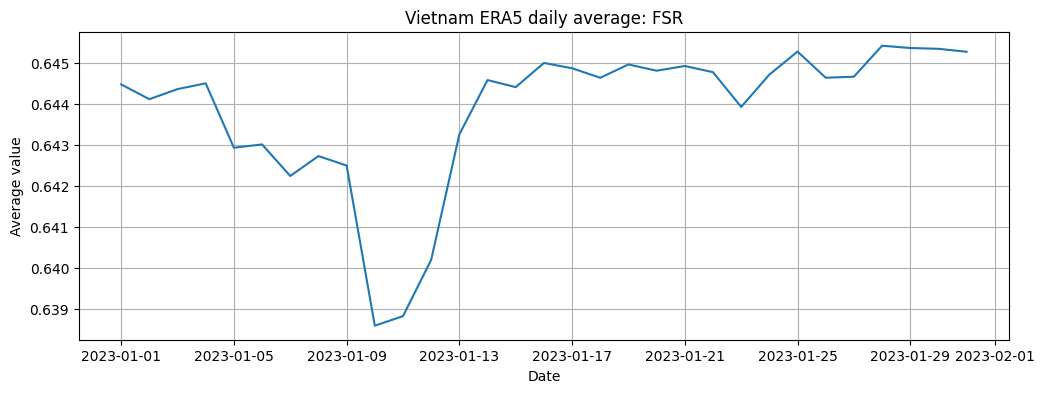

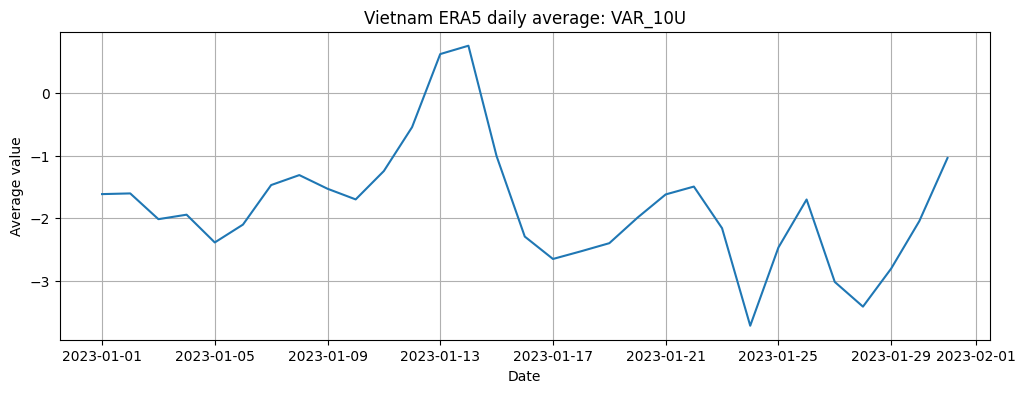

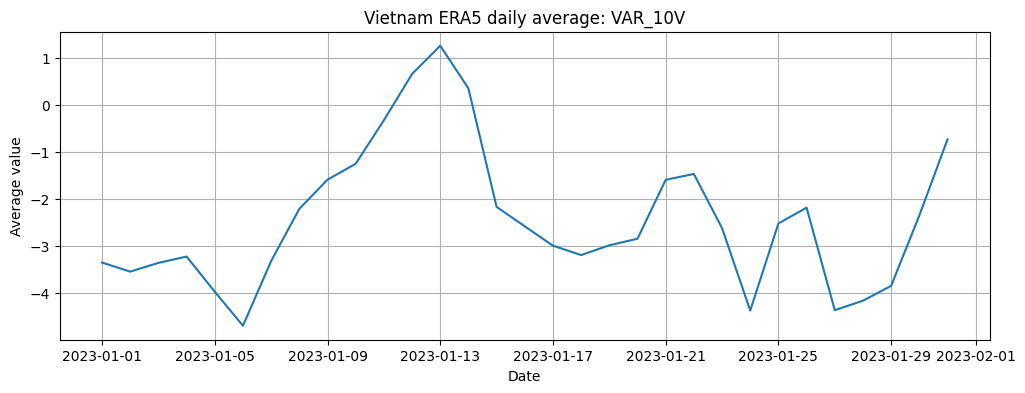

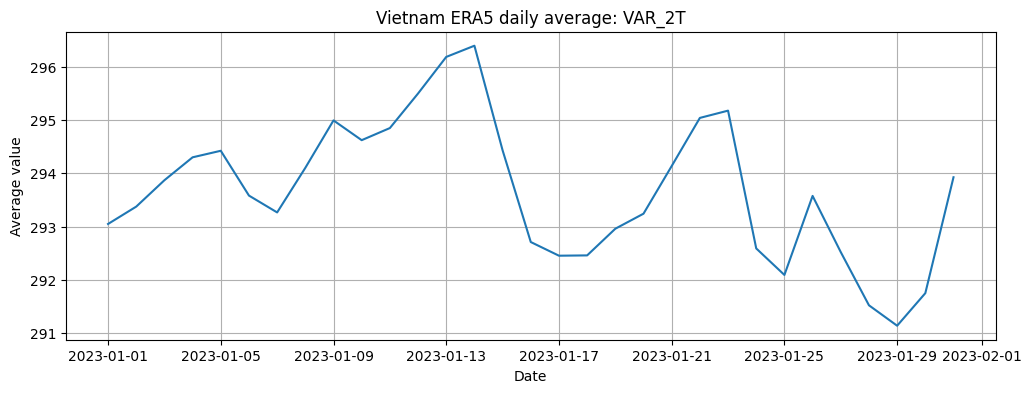

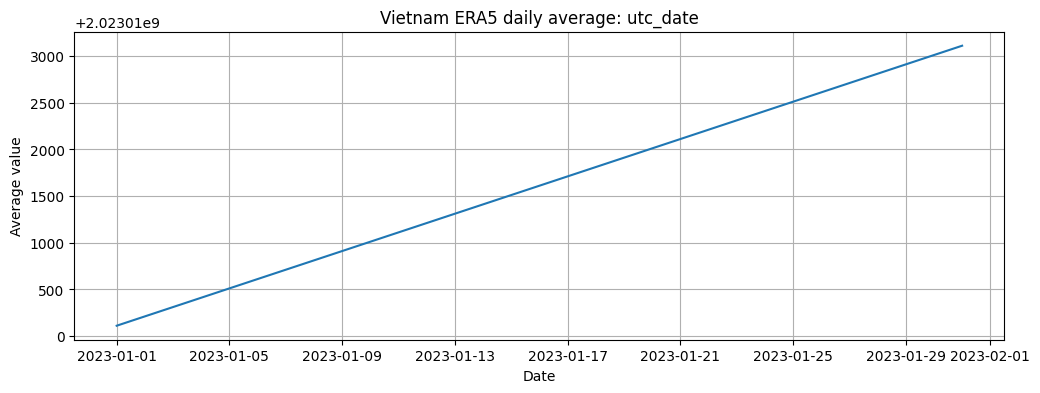

In [17]:
plot_df = daily_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

for var in plot_df["variable"].unique():
    tmp = plot_df[plot_df["variable"] == var]

    plt.figure(figsize=(12, 4))
    plt.plot(tmp["date"], tmp["avg_value"])
    plt.title(f"Vietnam ERA5 daily average: {var}")
    plt.xlabel("Date")
    plt.ylabel("Average value")
    plt.grid(True)
    plt.show()

In [18]:
# Create wide table from long daily_df
wide_df = daily_df.pivot_table(
    index=["date", "region", "year", "month", "lat_min", "lat_max", "lon_min", "lon_max"],
    columns="variable",
    values="avg_value",
    aggfunc="mean"
).reset_index()

wide_df.columns.name = None
print(wide_df.columns.tolist())
wide_df.head()

['date', 'region', 'year', 'month', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'FSR', 'VAR_10U', 'VAR_10V', 'VAR_2T', 'utc_date']


,date,region,year,month,lat_min,lat_max,lon_min,lon_max,FSR,VAR_10U,VAR_10V,VAR_2T,utc_date
0,2023-01-01,Vietnam,2023,1,8.0,24.0,102.0,110.0,0.644468,-1.616552,-3.346416,293.048962,2.023010e+09
1,2023-01-02,Vietnam,2023,1,8.0,24.0,102.0,110.0,0.644107,-1.605539,-3.538807,293.374308,2.023010e+09
2,2023-01-03,Vietnam,2023,1,8.0,24.0,102.0,110.0,0.644353,-2.017479,-3.353405,293.869104,2.023010e+09
3,2023-01-04,Vietnam,2023,1,8.0,24.0,102.0,110.0,0.644492,-1.945804,-3.219489,294.298768,2.023010e+09
4,2023-01-05,Vietnam,2023,1,8.0,24.0,102.0,110.0,0.642924,-2.389809,-3.965548,294.421450,2.023011e+09


In [19]:
# Inspect this output first
wide_df.columns.tolist()

['date',
 'region',
 'year',
 'month',
 'lat_min',
 'lat_max',
 'lon_min',
 'lon_max',
 'FSR',
 'VAR_10U',
 'VAR_10V',
 'VAR_2T',
 'utc_date']

In [20]:
clean_df = wide_df.copy()

rename_map = {
    "VAR_2M_TEMPERATURE": "avg_temp_k",
    "VAR_10M_U_WIND": "avg_u_wind_10m",
    "VAR_10M_V_WIND": "avg_v_wind_10m",
    "VAR_SOLAR_RADIATION": "solar_j_m2",
}

# Helper: auto-map common NCAR/ERA5 variable names
auto_candidates = {
    "avg_temp_k": ["2t", "t2m", "VAR_167", "T2M"],
    "avg_u_wind_10m": ["10u", "u10", "VAR_165", "U10"],
    "avg_v_wind_10m": ["10v", "v10", "VAR_166", "V10"],
    "solar_j_m2": ["ssrd", "fsr", "VAR_244", "SSR"],
}

for target, candidates in auto_candidates.items():
    for col in clean_df.columns:
        if any(c.lower() in col.lower() for c in candidates):
            clean_df = clean_df.rename(columns={col: target})
            print(f"Mapped {col} -> {target}")
            break

required_cols = ["avg_temp_k", "avg_u_wind_10m", "avg_v_wind_10m", "solar_j_m2"]
missing = [c for c in required_cols if c not in clean_df.columns]

if missing:
    print("Missing mapped columns:", missing)
    print("Available columns:", clean_df.columns.tolist())
else:
    clean_df["date"] = pd.to_datetime(clean_df["date"])
    clean_df["avg_temp_c"] = clean_df["avg_temp_k"] - 273.15
    clean_df["avg_wind_speed_10m"] = (
        clean_df["avg_u_wind_10m"] ** 2 + clean_df["avg_v_wind_10m"] ** 2
    ) ** 0.5
    clean_df["solar_mj_m2"] = clean_df["solar_j_m2"] / 1_000_000

    clean_df = clean_df[
        [
            "date",
            "region",
            "year",
            "month",
            "lat_min",
            "lat_max",
            "lon_min",
            "lon_max",
            "avg_temp_c",
            "avg_u_wind_10m",
            "avg_v_wind_10m",
            "avg_wind_speed_10m",
            "solar_mj_m2",
        ]
    ]

clean_df.head()

Mapped VAR_2T -> avg_temp_k
Mapped VAR_10U -> avg_u_wind_10m
Mapped VAR_10V -> avg_v_wind_10m
Mapped FSR -> solar_j_m2


,date,region,year,month,lat_min,lat_max,lon_min,lon_max,avg_temp_c,avg_u_wind_10m,avg_v_wind_10m,avg_wind_speed_10m,solar_mj_m2
0,2023-01-01,Vietnam,2023,1,8.0,24.0,102.0,110.0,19.898962,-1.616552,-3.346416,3.716415,6.444677e-07
1,2023-01-02,Vietnam,2023,1,8.0,24.0,102.0,110.0,20.224308,-1.605539,-3.538807,3.885989,6.441069e-07
2,2023-01-03,Vietnam,2023,1,8.0,24.0,102.0,110.0,20.719104,-2.017479,-3.353405,3.913508,6.443533e-07
3,2023-01-04,Vietnam,2023,1,8.0,24.0,102.0,110.0,21.148768,-1.945804,-3.219489,3.761816,6.444922e-07
4,2023-01-05,Vietnam,2023,1,8.0,24.0,102.0,110.0,21.271450,-2.389809,-3.965548,4.629985,6.429241e-07


In [21]:
# Baseline here is your current available period.
# Later, when you process 2014–2024, use 2014–2023 as baseline.
baseline_temp = clean_df["avg_temp_c"].mean()
baseline_solar = clean_df["solar_mj_m2"].mean()
baseline_wind = clean_df["avg_wind_speed_10m"].mean()

clean_df["temp_anomaly_c"] = clean_df["avg_temp_c"] - baseline_temp
clean_df["solar_anomaly_mj_m2"] = clean_df["solar_mj_m2"] - baseline_solar
clean_df["wind_anomaly_ms"] = clean_df["avg_wind_speed_10m"] - baseline_wind

clean_df["heat_risk_flag"] = clean_df["avg_temp_c"] >= clean_df["avg_temp_c"].quantile(0.9)

clean_df.head()

,date,region,year,month,lat_min,lat_max,lon_min,lon_max,avg_temp_c,avg_u_wind_10m,avg_v_wind_10m,avg_wind_speed_10m,solar_mj_m2,temp_anomaly_c,solar_anomaly_mj_m2,wind_anomaly_ms,heat_risk_flag
0,2023-01-01,Vietnam,2023,1,8.0,24.0,102.0,110.0,19.898962,-1.616552,-3.346416,3.716415,6.444677e-07,-0.635183,6.268334e-10,0.466246,False
1,2023-01-02,Vietnam,2023,1,8.0,24.0,102.0,110.0,20.224308,-1.605539,-3.538807,3.885989,6.441069e-07,-0.309836,2.660490e-10,0.635820,False
2,2023-01-03,Vietnam,2023,1,8.0,24.0,102.0,110.0,20.719104,-2.017479,-3.353405,3.913508,6.443533e-07,0.184959,5.124447e-10,0.663338,False
3,2023-01-04,Vietnam,2023,1,8.0,24.0,102.0,110.0,21.148768,-1.945804,-3.219489,3.761816,6.444922e-07,0.614624,6.513707e-10,0.511646,False
4,2023-01-05,Vietnam,2023,1,8.0,24.0,102.0,110.0,21.271450,-2.389809,-3.965548,4.629985,6.429241e-07,0.737306,-9.167654e-10,1.379815,False


In [22]:
monthly_df = (
    clean_df
    .assign(month_start=clean_df["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month_start", "region"], as_index=False)
    .agg(
        avg_temp_c=("avg_temp_c", "mean"),
        max_temp_c=("avg_temp_c", "max"),
        avg_wind_speed_10m=("avg_wind_speed_10m", "mean"),
        avg_solar_mj_m2=("solar_mj_m2", "mean"),
        avg_temp_anomaly_c=("temp_anomaly_c", "mean"),
        heat_risk_days=("heat_risk_flag", "sum"),
        n_days=("date", "count"),
    )
)

monthly_df.head()

,month_start,region,avg_temp_c,max_temp_c,avg_wind_speed_10m,avg_solar_mj_m2,avg_temp_anomaly_c,heat_risk_days,n_days
0,2023-01-01,Vietnam,20.534145,23.241198,3.25017,6.438408e-07,-1.604451e-15,4,31


In [23]:
MART_DIR = Path("mart")
MART_DIR.mkdir(exist_ok=True)

daily_mart_file = MART_DIR / f"era5_vietnam_climate_energy_daily_{YEAR}_{MONTH:02d}.parquet"
monthly_mart_file = MART_DIR / f"era5_vietnam_climate_energy_monthly_{YEAR}_{MONTH:02d}.parquet"

clean_df.to_parquet(daily_mart_file, index=False)
monthly_df.to_parquet(monthly_mart_file, index=False)

print("Saved daily mart:", daily_mart_file)
print("Saved monthly mart:", monthly_mart_file)

Saved daily mart: mart/era5_vietnam_climate_energy_daily_2023_01.parquet
Saved monthly mart: mart/era5_vietnam_climate_energy_monthly_2023_01.parquet


In [24]:
import os
import getpass
import boto3

AWS_ACCESS_KEY_ID = getpass.getpass("AWS_ACCESS_KEY_ID: ")
AWS_SECRET_ACCESS_KEY = getpass.getpass("AWS_SECRET_ACCESS_KEY: ")
AWS_REGION = "ap-southeast-1"

os.environ["AWS_ACCESS_KEY_ID"] = AWS_ACCESS_KEY_ID
os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET_ACCESS_KEY
os.environ["AWS_DEFAULT_REGION"] = AWS_REGION

s3_private = boto3.client("s3", region_name=AWS_REGION)

AWS_ACCESS_KEY_ID: ··········
AWS_SECRET_ACCESS_KEY: ··········
AWS_ACCESS_KEY_ID: ··········
AWS_SECRET_ACCESS_KEY: ··········


In [25]:
def upload_to_s3(local_file, bucket, key):
    s3 = boto3.client("s3", region_name="ap-southeast-1")

    s3.upload_file(
        Filename=str(local_file),
        Bucket=bucket,
        Key=key
    )

    print(f"Uploaded: s3://{bucket}/{key}")

In [26]:
YEAR = 2023
MONTH = 1

daily_key = f"marts/era5_vietnam_daily/year={YEAR}/month={MONTH:02d}/era5_vietnam_climate_energy_daily_{YEAR}_{MONTH:02d}.parquet"

monthly_key = f"marts/era5_vietnam_monthly/year={YEAR}/month={MONTH:02d}/era5_vietnam_climate_energy_monthly_{YEAR}_{MONTH:02d}.parquet"

In [27]:
MY_BUCKET = "hoa-era5-climate-lake"

upload_to_s3(daily_mart_file, MY_BUCKET, daily_key)
upload_to_s3(monthly_mart_file, MY_BUCKET, monthly_key)

Uploaded: s3://hoa-era5-climate-lake/marts/era5_vietnam_daily/year=2023/month=01/era5_vietnam_climate_energy_daily_2023_01.parquet
Uploaded: s3://hoa-era5-climate-lake/marts/era5_vietnam_monthly/year=2023/month=01/era5_vietnam_climate_energy_monthly_2023_01.parquet


In [28]:
MY_BUCKET = "hoa-era5-climate-lake"

def upload_to_s3(local_file, bucket, key):
    s3_private.upload_file(
        Filename=str(local_file),
        Bucket=bucket,
        Key=key
    )
    print(f"Uploaded: s3://{bucket}/{key}")

daily_key = f"marts/era5_vietnam_daily/year={YEAR}/month={MONTH:02d}/{daily_mart_file.name}"
monthly_key = f"marts/era5_vietnam_monthly/year={YEAR}/month={MONTH:02d}/{monthly_mart_file.name}"

upload_to_s3(daily_mart_file, MY_BUCKET, daily_key)
upload_to_s3(monthly_mart_file, MY_BUCKET, monthly_key)

Uploaded: s3://hoa-era5-climate-lake/marts/era5_vietnam_daily/year=2023/month=01/era5_vietnam_climate_energy_daily_2023_01.parquet
Uploaded: s3://hoa-era5-climate-lake/marts/era5_vietnam_monthly/year=2023/month=01/era5_vietnam_climate_energy_monthly_2023_01.parquet


In [29]:
pip install streamlit pandas pyathena plotly

In [30]:
from pyathena import connect
# === CONFIG ===
S3_STAGING_DIR = "s3://hoa-era5-climate-lake/athena-results/"
AWS_REGION = "ap-southeast-1"
DATABASE = "climate_analytics"

conn = connect(
    s3_staging_dir=S3_STAGING_DIR,
    region_name=AWS_REGION,
    schema_name=DATABASE,
    work_group="primary"
)

In [31]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import plotly.express as px
from pyathena import connect

AWS_REGION = "ap-southeast-1"
S3_STAGING_DIR = "s3://hoa-era5-climate-lake/athena-results/"
DATABASE = "climate_analytics"
TABLE = "era5_vietnam_daily"

st.set_page_config(
    page_title="Vietnam ERA5 Climate-Energy Dashboard",
    layout="wide"
)

st.title("Vietnam ERA5 Climate-Energy Dashboard")
st.caption("ERA5 climate reanalysis data processed into S3 Parquet and queried through Amazon Athena")

@st.cache_data(ttl=3600)
def load_data():
    conn = connect(
        s3_staging_dir=S3_STAGING_DIR,
        region_name=AWS_REGION,
        schema_name=DATABASE,
    )

    query = f"""
    SELECT
        date,
        region,
        year,
        month,
        avg_temp_c,
        avg_wind_speed_10m,
        solar_mj_m2,
        temp_anomaly_c,
        solar_anomaly_mj_m2,
        wind_anomaly_ms,
        heat_risk_flag
    FROM {DATABASE}.{TABLE}
    ORDER BY date
    """

    df = pd.read_sql(query, conn)
    df["date"] = pd.to_datetime(df["date"])
    return df

df = load_data()

st.sidebar.header("Filters")

years = sorted(df["year"].unique())
selected_years = st.sidebar.multiselect(
    "Year",
    years,
    default=years
)

filtered = df[df["year"].isin(selected_years)]

st.subheader("Key indicators")

col1, col2, col3, col4 = st.columns(4)

col1.metric("Average temperature", f"{filtered['avg_temp_c'].mean():.2f} °C")
col2.metric("Average wind speed", f"{filtered['avg_wind_speed_10m'].mean():.2f} m/s")
col3.metric("Average solar radiation", f"{filtered['solar_mj_m2'].mean():.2f} MJ/m²")
col4.metric("Heat-risk days", int(filtered["heat_risk_flag"].sum()))

st.divider()

st.subheader("Daily temperature trend")

fig_temp = px.line(
    filtered,
    x="date",
    y="avg_temp_c",
    title="Daily Average Temperature in Vietnam"
)
st.plotly_chart(fig_temp, use_container_width=True)

st.subheader("Temperature anomaly")

fig_anomaly = px.line(
    filtered,
    x="date",
    y="temp_anomaly_c",
    title="Temperature Anomaly Compared with Available Baseline"
)
st.plotly_chart(fig_anomaly, use_container_width=True)

st.subheader("Wind and solar potential")

col_a, col_b = st.columns(2)

with col_a:
    fig_wind = px.line(
        filtered,
        x="date",
        y="avg_wind_speed_10m",
        title="Daily Average 10m Wind Speed"
    )
    st.plotly_chart(fig_wind, use_container_width=True)

with col_b:
    fig_solar = px.line(
        filtered,
        x="date",
        y="solar_mj_m2",
        title="Daily Solar Radiation"
    )
    st.plotly_chart(fig_solar, use_container_width=True)

st.subheader("Monthly summary")

monthly = (
    filtered
    .groupby(["year", "month"], as_index=False)
    .agg(
        avg_temp_c=("avg_temp_c", "mean"),
        avg_wind_speed_10m=("avg_wind_speed_10m", "mean"),
        avg_solar_mj_m2=("solar_mj_m2", "mean"),
        heat_risk_days=("heat_risk_flag", "sum"),
    )
)

monthly["period"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)

st.dataframe(monthly, use_container_width=True)

fig_monthly = px.bar(
    monthly,
    x="period",
    y="heat_risk_days",
    title="Monthly Heat-Risk Days"
)
st.plotly_chart(fig_monthly, use_container_width=True)

st.subheader("Raw data sample")
st.dataframe(filtered.head(100), use_container_width=True)

Overwriting dashboard.py


In [34]:
!streamlit run dashboard.py --server.port 8501 > /content/logs.txt 2>&1 &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://purple-grapes-flow.loca.lt
